## Here is an example

In [1]:
import json
import openai
import os 

def load_api_key(secrets_file="/home/kaichiht/openai.json"):
    with open(secrets_file) as f:
        secrets = json.load(f)
    return secrets["OPENAI_API_KEY"]

# Set secret API key
# Typically, we'd use an environment variable (e.g., echo "export OPENAI_API_KEY='yourkey'" >> ~/.zshrc)
# However, using "internalConsole" in launch.json requires setting it in the code for compatibility with Hebrew
api_key = load_api_key()
openai.api_key = api_key

%reload_ext jupyter_ai

os.environ["OPENAI_API_KEY"]=openai.api_key

ModuleNotFoundError: No module named 'openai'

In [2]:
%%ai chatgpt
how to import h5py library 

UsageError: Cell magic `%%ai` not found.


In [118]:
import h5py
PR=50
with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/prec/PR{PR}_500_20000day_6hourly_prec_0_600hPa_sum.dat"
) as f:
        prec = f["prec"][:, :]

In [28]:
# This program is to reconstruct the signal of the signal of Kelvin waves
# Basic Settring 
# # import package
import sys
import h5py
import numpy as np

from cartopy import crs as ccrs
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter 

from matplotlib import colors as cm
from matplotlib import pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import sys
import os
import importlib.util

# Define the path to the Theory.py file directly
theory_file_path = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/PowerSpec_Dycore/Package/Theory.py"

# Load the module from the file path
spec = importlib.util.spec_from_file_location("Theory", theory_file_path)
th = importlib.util.module_from_spec(spec)
sys.modules["Theory"] = th
spec.loader.exec_module(th)

level_index = 2

# level_index = 18

# sys.path.append("/home/b11209013/Package/")
sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/PowerSpec_Dycore/Package/")
import Theory as th

# Verify that it's the correct module
print(th)
# ================== #
# functions
# # plot setting
def plot_setting():
    plt.rcParams["axes.titlesize"] = 14
    plt.rcParams["axes.labelsize"] = 12
    plt.rcParams["xtick.labelsize"] = 10
    plt.rcParams["ytick.labelsize"] = 10
    plt.rcParams["font.family"] = "serif"

# ================== #
# main function
def main(PR):
    # load data
    path:str = f"/home/b11209013/2024_Research/PowerSpec_Dycore/data/pr{PR}/"

    # # range latitude
    lat = np.linspace(-90, 90, 64)
    
    lat_cond = np.where((lat>=-15)&(lat<=15))[0]
    # lat_cond = np.where((lat>=-45)&(lat<=45))[0]
    
    lat = lat[lat_cond]
    print(lat)
    # prec data
    # with h5py.File(path+"prec_pr50.dat") as f:
    with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/prec/PR{PR}_500_20000day_6hourly_prec_0_600hPa_sum.dat"
) as f:
        prec = f["prec"][:, lat_cond]
    prec -= prec.mean(axis=0)
    prec *= 86400
    
    
    # u-wind
    # with h5py.File(path+"u_pr50.dat") as f:
        # u = f["u"][:, 5, lat_cond]

    # u -= u.mean(axis=0)

    # pressure
    with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/p/PR{PR}_500_20000day_6hourly_p.dat") as f:
        p = f["p"][:, level_index, lat_cond]
    p -= p.mean(axis=0)

    # z
    with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/z/PR{PR}_500_20000day_6hourly_z.dat") as f:
        z = f["z"][:, level_index, lat_cond]
    z -= z.mean(axis=0)

    with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/vor/PR{PR}_500_20000day_6hourly_vor.dat") as f:
        vor = f["vor"][:, level_index, :]
    vor -= vor.mean(axis=0)




    # ================= #
    # Reconstruct Kelvin waves
    # # FFT
    # precpitation
    prec_fft = np.array([
        np.fft.fftshift(np.fft.fft2(prec[:, i, :]))[:, ::-1]
        for i in range(len(lat_cond))
        ])
    # (lat, time, lon)

    p_fft = np.array([
        np.fft.fftshift(np.fft.fft2(p[:, i, :]))[:, ::-1]
        for i in range(len(lat_cond))
        ])

    z_fft = np.array([
        np.fft.fftshift(np.fft.fft2(z[:, i, :]))[:, ::-1]
        for i in range(len(lat_cond))
        ])

    vor_fft = np.array([
        np.fft.fftshift(np.fft.fft2(vor[:, i, :]))[:, ::-1]
        for i in range(len(lat_cond))
        ])

    # # # u-wind
    # u_fft = np.array([
    #     np.fft.fftshift(np.fft.fft2(u[:, i, :]))[:, ::-1]
    #     for i in range(len(lat_cond))
    #     ])

    # # # # v-wind
    # v_fft = np.array([
    #     np.fft.fftshift(np.fft.fft2(v[:, i, :]))[:, ::-1]
    #     for i in range(len(lat_cond))
    #     ])


    # # dimension for bandpass filter
    wn = np.linspace(-64, 64, 128)
    fr = np.linspace(-2, 2, 78000)

    wnm, frm = np.meshgrid(wn, fr)
    kel_curves = lambda k, ed: (86400/(2*np.pi*6.371e6))*np.sqrt(9.81*ed)*k

    ed8 = kel_curves(wnm, 8)
    ed25 = kel_curves(wnm, 25)
    ed90 = kel_curves(wnm, 90)

    # cond = np.logical_or.reduce([
    #     wnm <= 1, wnm >= 6,
    #     # frm > -0.05, frm < -0.5,     
    #     frm > -0.01, frm < -0.15,     
        
    #     # frm >= -ed8.Kelvin(), frm <= -ed90.Kelvin()
    #     frm >= -ed8.Kelvin(), frm <= -ed25.Kelvin()
        
    #     ])
    cond = (
    (wnm >= 0) & (wnm <= 3) &
    (frm >= 0.) & (frm <= 0.2) &
    (frm <= ed90) & (frm >= ed8)
)
    
    # # bandpass filter and inverse FFT
    # # # IFFT
    prec_ifft = []
    # u_ifft = []
    # v_ifft = []
    p_ifft = []
    z_ifft = []
    vor_ifft = []
    
    

    # for i in range(len(lat_cond)):
    #     prec_filted = np.where(cond == True, 0, prec_fft[i]*2)
    #     prec_ifft.append(np.fft.ifft2(np.fft.ifftshift(prec_filted)))


    #     # u_filted = np.where(cond == True, 0, u_fft[i]*2)
    #     # u_ifft.append(np.fft.ifft2(np.fft.ifftshift(u_filted)))

    #     # v_filted = np.where(cond == True, 0, v_fft[i]*2)
    #     # v_ifft.append(np.fft.ifft2(np.fft.ifftshift(v_filted)))

    #     p_filted = np.where(cond == True, 0, p_fft[i]*2)
    #     p_ifft.append(np.fft.ifft2(np.fft.ifftshift(p_filted)))

    #     z_filted = np.where(cond == True, 0, z_fft[i]*2)
    #     z_ifft.append(np.fft.ifft2(np.fft.ifftshift(z_filted)))


        # Applying the bandpass filter and inverse FFT
    def apply_ifft_with_filter(data_fft, cond):
        return np.stack([
            np.fft.ifft2(np.fft.ifftshift(np.where(cond, data_fft[i] * 2, 0)[:,::-1])).real
            for i in range(data_fft.shape[0])
        ], axis=1)

    # Reconstructing signals
    prec_recon = apply_ifft_with_filter(prec_fft, cond)
    p_recon = apply_ifft_with_filter(p_fft, cond)
    z_recon = apply_ifft_with_filter(z_fft, cond)
    vor_recon = apply_ifft_with_filter(vor_fft, cond)
    

    

    return prec_recon, p_recon, z_recon, vor_recon
# ===================== #
# execution section
if __name__ == "__main__":
    PR = 50
    # prec_recon, p_recon = main(PR)
    prec_recon, p_recon, z_recon, vor_recon = main(PR)
    
    print("done")

#########################################################




<module 'Theory' from '/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/PowerSpec_Dycore/Package/Theory.py'>
[-12.85714286 -10.          -7.14285714  -4.28571429  -1.42857143
   1.42857143   4.28571429   7.14285714  10.          12.85714286]
done


In [29]:
# load data
PR = 50
lat         = np.linspace(-90, 90, 64)
lat_cond    = np.where((lat>=-15)&(lat<=15))[0]
level_index = 2
with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/z/PR{PR}_500_20000day_6hourly_z.dat") as f:
    z = f["z"][:, level_index, :]
z -= z.mean(axis=0)

with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/prec/PR{PR}_500_20000day_6hourly_prec_0_600hPa_sum.dat"
) as f:
        prec = f["prec"][:, :]
prec -= prec.mean(axis=0)
prec *= 86400

with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/p/PR{PR}_500_20000day_6hourly_p.dat") as f:
        p = f["p"][:, level_index, :]
p -= p.mean(axis=0)


# plt.figure()
# plt.contourf(tmp)

In [30]:
with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/vor/PR{PR}_500_20000day_6hourly_vor.dat") as f:
        vor = f["vor"][:, level_index, :]
vor -= vor.mean(axis=0)



In [23]:
print(PR)

50


In [6]:
import numpy as np
import matplotlib.pyplot as plt


def fft_filtering(data,dim,wave_numbers):
    n_points = data.shape[dim]
    n_dim    = data.ndim
    print(n_points)
    print(n_dim)
    # move the dimension of interest to the first place 
    order             = ['i','j','k','l','m','n']
    old_dim  = ""
    for i in range(dim+1):
        old_dim         += str(order[i])
    print(old_dim)

    order.insert(0, order.pop(dim))
    new_dim  = ""
    for i in range(dim+1):
        new_dim         += str(order[i])
    print(new_dim)
    # Perform FFT
    fft_values     = np.fft.fft(data,axis=dim)
    frequencies    = np.fft.fftfreq(n_points)

    # swapped data order 
    fft_values     = np.einsum(old_dim+'->'+new_dim, fft_values)

    # find which wave number should be kept
    posi           = np.where(np.isin(np.abs(frequencies*n_points),wave_numbers))[0]

    # filtering data
    filtered_data  = np.zeros_like(fft_values)
    filtered_data[posi,:] = fft_values[posi,:]
    
    # swapped back to original order 
    filtered_data  = np.einsum(new_dim+'->'+old_dim, filtered_data)
    filtered_data  = np.fft.ifft(filtered_data,axis=dim).real
    
  
    return filtered_data




In [679]:
%%ai chatgpt
how to tell if a variable exist in python

To check if a variable exists in Python, you can use the `globals()` function to access the global namespace and then use the `in` keyword to check if the variable is present. Here is an example code snippet:

```python
variable_name = 'example_variable'

if 'variable_name' in globals():
    print('Variable exists')
else:
    print('Variable does not exist')
```

Replace `'example_variable'` with the name of the variable you want to check for existence. This code will output whether the variable exists or not in the global namespace.

In [7]:
if 'z_wn1' in globals():
    print('Variable exists')
else:
    print('Variable does not exist')

Variable does not exist


128
3
ijk
kij
128
3
ijk
kij
128
3
ijk
kij


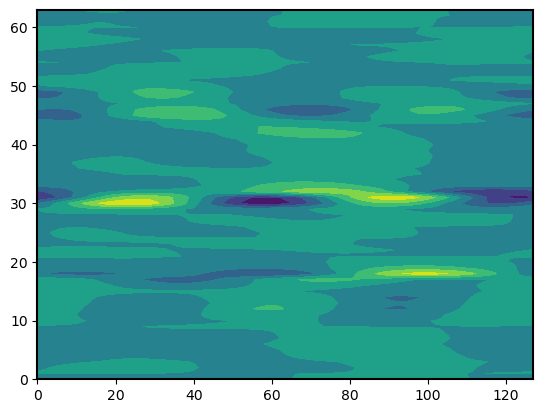

In [31]:
if 'z_wn1' in globals():
    del z_wn1
if 'prec_wn1' in globals():
    del prec_wn1
if 'vor_wn1' in globals():
    del vor_wn1

prec_wn1   = fft_filtering(prec,dim=2,wave_numbers=[1,2])
z_wn1      = fft_filtering(z,dim=2,wave_numbers=[1,2,3,4,5,6])
vor_wn1    = fft_filtering(vor,dim=2,wave_numbers=[1,2,3,4,5,6])

plt.figure()
plt.contourf(prec_wn1[500,:,:])


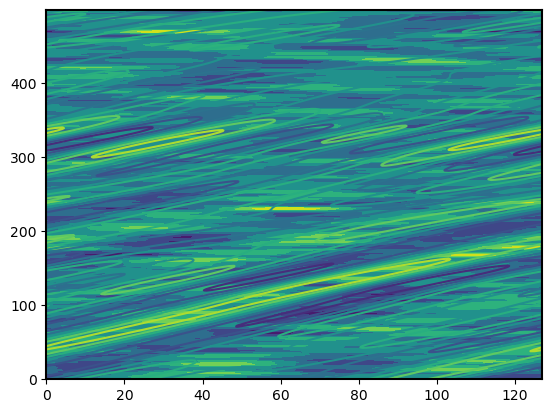

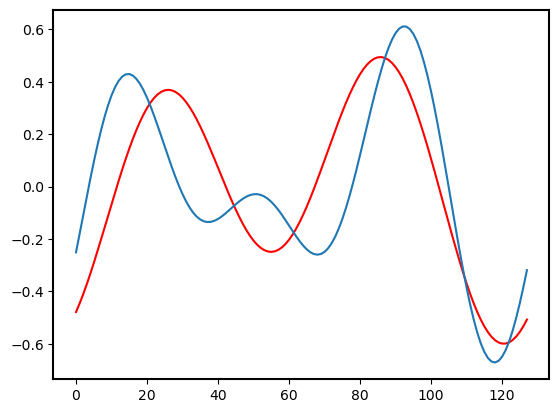

In [33]:
plt.figure()
plt.contourf(prec_wn1[500:1000,lat_cond,:].mean(axis=1))
plt.contour(prec_recon[500:1000,:,:].mean(axis=1))

plt.figure()
plt.plot(prec_wn1[500,lat_cond,:].mean(axis=0),'r')
plt.plot(prec_recon[500,:,:].mean(axis=0))

In [759]:
%%ai chatgpt 
how to deepcopy a array in python

```python
import copy

# Original array
original_arr = [1, 2, 3, 4, 5]

# Deepcopy of the array
deepcopy_arr = copy.deepcopy(original_arr)

print(deepcopy_arr)
```

In [34]:
import copy
# rolling the data and make composite all over again 
variables_to_delete = ['tmp','tmp_z','tmp_prec_wn1','tmp_z_wn1', 'tmp_vor_wn1']

for variable in variables_to_delete:
    if variable in globals():
        del globals()[variable]
    
tmp                = prec_recon.mean(axis=1)[:,:]
tmp_z              = copy.deepcopy(z[:,:,:].reshape([78000*64,128]))
tmp_prec_wn1       = copy.deepcopy(prec_wn1[:,:,:].reshape([78000*64,128]))
tmp_z_wn1          = copy.deepcopy(z_wn1[:,:,:].reshape([78000*64,128]))
tmp_vor_wn1        = copy.deepcopy(vor_wn1[:,:,:].reshape([78000*64,128]))

posi_time,posi_x = np.where(tmp == np.max(tmp,axis=1)[:,np.newaxis])

lag = 5*4 
for i in range(tmp.shape[0]):
    if i >= (78000-lag):
        pass
    else:
        tmp[(i+lag),:]                        = np.roll(tmp[(i+lag),:], 64-posi_x[i])
        tmp_z[(i+lag)*64:((i+lag)+1)*64,:]          = np.roll(tmp_z[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])
        tmp_prec_wn1[(i+lag)*64:((i+lag)+1)*64,:]   = np.roll(tmp_prec_wn1[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])
        tmp_z_wn1[(i+lag)*64:((i+lag)+1)*64,:]      = np.roll(tmp_z_wn1[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])
        
        tmp_vor_wn1[(i+lag)*64:((i+lag)+1)*64,:]      = np.roll(tmp_vor_wn1[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])
        



50


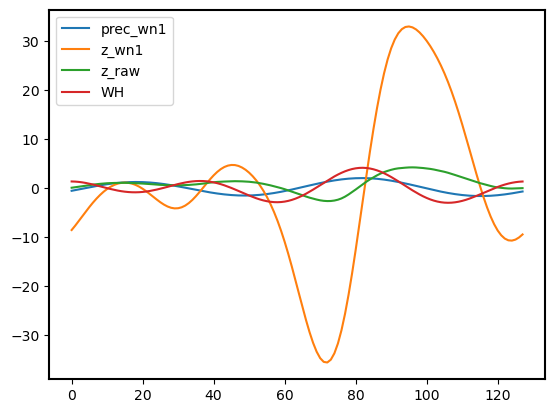

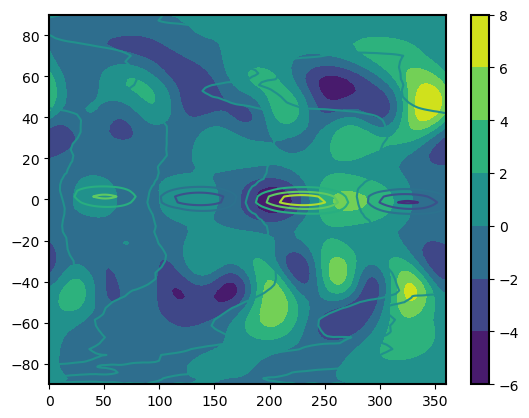

In [35]:
tmp_prec_wn1 = tmp_prec_wn1.reshape([78000,64,128])
tmp_z_wn1    = tmp_z_wn1.reshape([78000,64,128])
tmp_vor_wn1  = tmp_vor_wn1.reshape([78000,64,128])
tmp_z        = tmp_z.reshape([78000,64,128])


plt.figure()
plt.plot(tmp_prec_wn1[:,lat_cond,:].mean(axis=(0,1))*10,label='prec_wn1')
plt.plot(tmp_z_wn1[:,lat_cond,:].mean(axis=(0,1))*10,label='z_wn1')
plt.plot(tmp_z[:,lat_cond,:].mean(axis=(0,1)),label='z_raw')
plt.plot(tmp[:,:].mean(axis=(0))*10,label='WH')
plt.legend()

x = np.linspace(0,360,128)
y = np.linspace(-90,90,64)
xx, yy = np.meshgrid(x,y)

plt.figure()
CS = plt.contourf(xx,yy,tmp_z_wn1[:,:,:].mean(axis=(0))-tmp_z_wn1[:,:,:].mean(axis=(0,2))[:,np.newaxis])
# CS = plt.contourf(xx,yy,tmp_vor_wn1[:,:,:].mean(axis=(0))-tmp_vor_wn1[:,:,:].mean(axis=(0,2))[:,np.newaxis])

plt.contour(xx,yy,tmp_prec_wn1[:,:,:].mean(axis=(0)))
#plt.ylim([-30,30])
plt.colorbar(CS)
print(PR)

In [19]:
import copy
# rolling the data and make composite all over again 
variables_to_delete = ['tmp','tmp_z','tmp_prec_wn1','tmp_z_wn1']

for variable in variables_to_delete:
    if variable in globals():
        del globals()[variable]
    
tmp              = prec_recon.mean(axis=1)[:,:]
tmp_z            = copy.deepcopy(z[:,:,:].reshape([78000*64,128]))
tmp_prec_wn1     = copy.deepcopy(prec_wn1[:,:,:].reshape([78000*64,128]))
tmp_z_wn1        = copy.deepcopy(z_wn1[:,:,:].reshape([78000*64,128]))



posi_time,posi_x = np.where(tmp == np.max(tmp,axis=1)[:,np.newaxis])
lag = 5*4 
for i in range(tmp.shape[0]):
    if i >= (78000-lag):
        pass
    else:
        tmp[(i+lag),:]                        = np.roll(tmp[(i+lag),:], 64-posi_x[i])
        tmp_z[(i+lag)*64:((i+lag)+1)*64,:]          = np.roll(tmp_z[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])
        tmp_prec_wn1[(i+lag)*64:((i+lag)+1)*64,:]   = np.roll(tmp_prec_wn1[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])
        tmp_z_wn1[(i+lag)*64:((i+lag)+1)*64,:]      = np.roll(tmp_z_wn1[(i+lag)*64:((i+lag)+1)*64,:], 64-posi_x[i])





(78000, 64, 128)


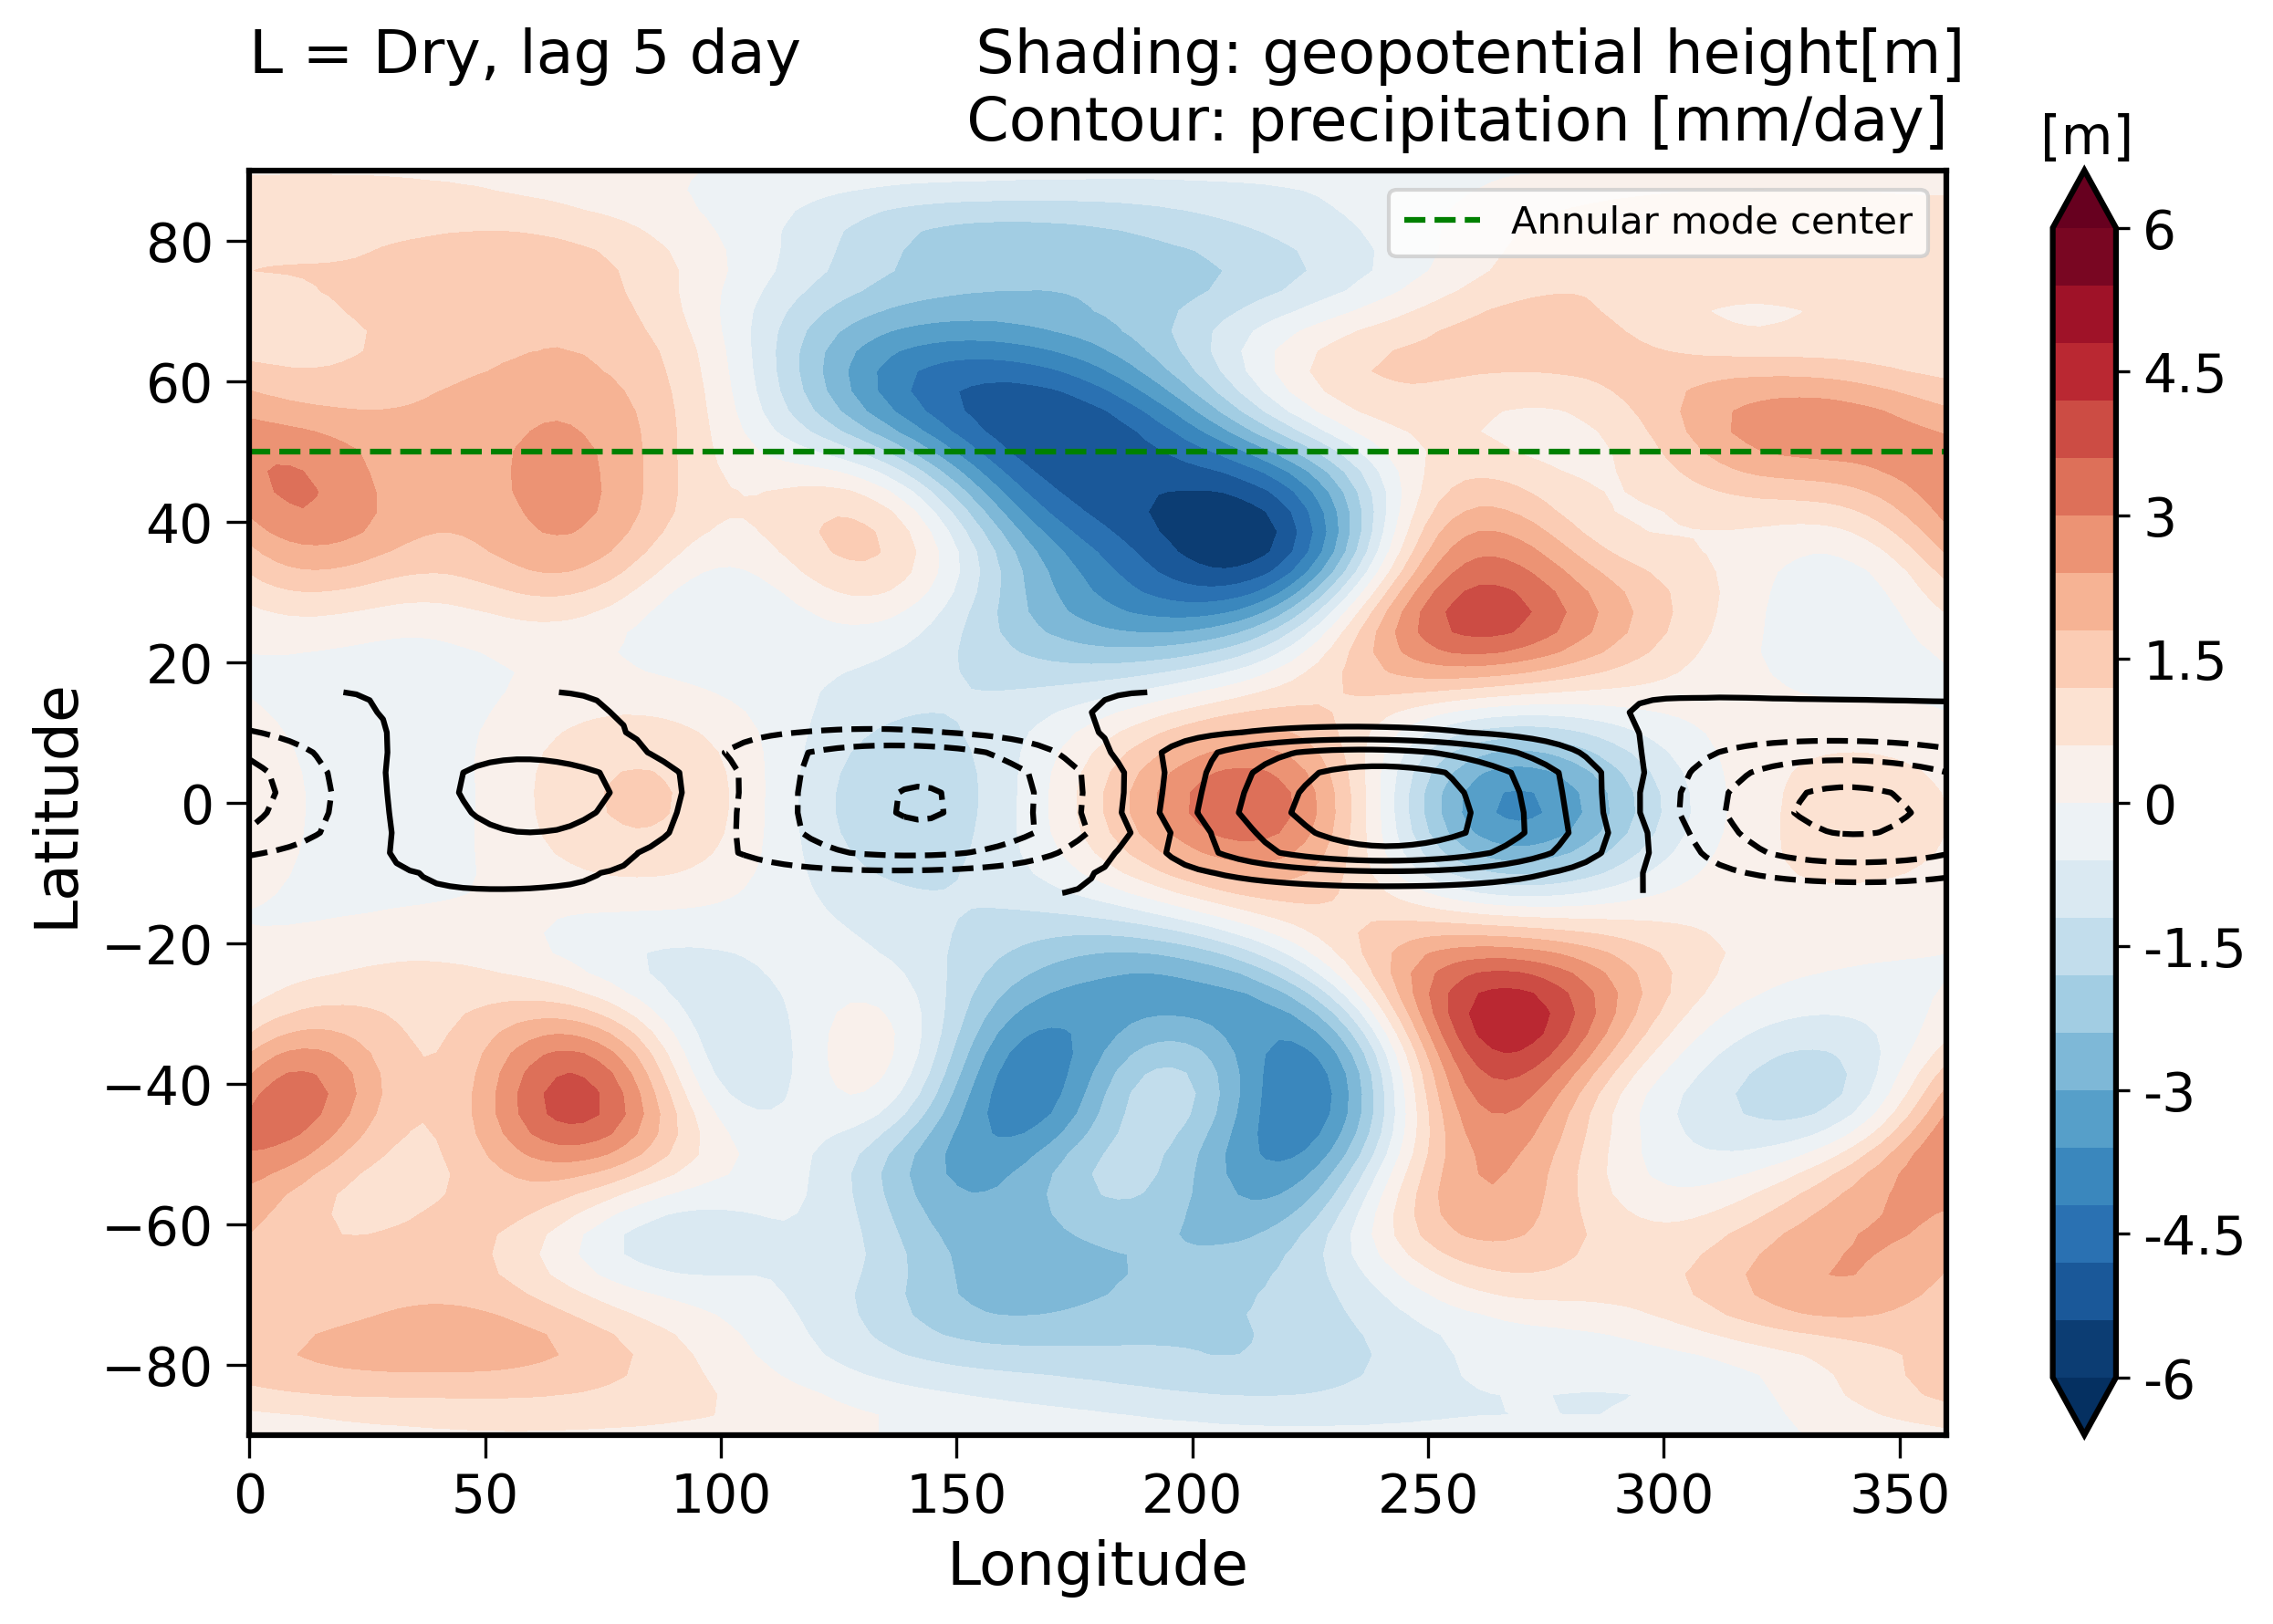

In [20]:
tmp_prec_wn1 = tmp_prec_wn1.reshape([78000,64,128])
tmp_z_wn1    = tmp_z_wn1.reshape([78000,64,128])
tmp_z        = tmp_z.reshape([78000,64,128])

# Set up meshgrid for plotting
x = np.linspace(0, 360, 128)
y = np.linspace(-90, 90, 64)
xx, yy = np.meshgrid(x, y)

import matplotlib as mpl
mpl.rcParams['axes.linewidth'] = 1.5

fig, ax = plt.subplots(1, figsize=(10,6), dpi=300.)
ax.set_title("L = Dry, lag 5 day         Shading: geopotential height[m]\n                                     Contour: precipitation [mm/day]", pad=8, fontsize=16, loc="left")  # Increase padding for title

# Call your custom plotting function with adjusted color limits
# _, custom_levels_bar, cs = plot_contourf_near0_fixcolorbar(
#     x, y, 
#     tmp_z_wn1[:,:,:].mean(axis=0) - tmp_z_wn1[:,:,:].mean(axis=(0,2))[:, np.newaxis], 
#     cbar_lim=[-6, 6],
#     my_cmap='coolwarm'
# )
print(tmp_z_wn1.shape)

cs = plt.contourf(xx, yy, tmp_z_wn1.mean(axis=0) - tmp_z_wn1.mean(axis=(0,2))[:, np.newaxis], cmap="RdBu_r", levels=np.linspace(-6,6,21), extend="both")
# Set axis labels
ax.set_xlabel("Longitude", fontsize=16)
ax.set_ylabel("Latitude", fontsize=16)

# Add contours
lats = 27
latn = 38
contour = ax.contour(xx[lats:latn,:], yy[lats:latn,:], tmp_prec_wn1[:,lats:latn,:].mean(axis=0), colors="Black")
# Add colorbar without shrinking the figure
# cbar_ax = fig.add_axes([0.91, 0.111, 0.015, 0.768])  # Adjusts the position of the colorbar
# cb = plt.colorbar(mappable=cs, cax=cbar_ax, spacing="proportional")
cb = plt.colorbar(cs)

# cb.set_ticks(custom_levels_bar)
plt.hlines(y=50, xmin=0, xmax=360, colors="Green", linestyle="--", label="Annular mode center")
cb.set_label("[m]", labelpad=-42, y=1.1, rotation=0, fontsize=14)
cb.set_ticks([-6, -4.5, -3, -1.5, 0, 1.5, 3, 4.5, 6])  # Set specific tick positions
cb.set_ticklabels(['-6', '-4.5', '-3', '-1.5', '0', '1.5', '3', '4.5', '6'])  # Set specific tick labels
cb.ax.tick_params(labelsize=14)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(direction='out', length=6)
plt.legend()

# Adjust plot spacing to ensure title and colorbar are properly displayed
# plt.savefig(f"/data92/PeterChang/Figs-113-1Seminar/Gill_PR{PR}/{lag}.png", bbox_inches='tight', dpi=300.)
plt.show()


In [14]:
import numpy as np
import copy
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set up general settings
x = np.linspace(0, 360, 128)
y = np.linspace(-90, 90, 64)
xx, yy = np.meshgrid(x, y)
mpl.rcParams['axes.linewidth'] = 1.5
savepath = f"/data92/PeterChang/Figs-113-1Seminar/Gill_PR{PR}/"

# Define the range for the loop
for lag in range(0, 8 * 4 + 1):  # Goes from 0 to 8*4
# for lag in range(0, 2):  # Goes from 0 to 8*4

    # Reset and roll data based on current lag, deleting previous data
    tmp = prec_recon.mean(axis=1)[:,:]
    tmp_z = copy.deepcopy(z[:,:,:].reshape([78000 * 64, 128]))
    tmp_prec_wn1 = copy.deepcopy(prec_wn1[:,:,:].reshape([78000 * 64, 128]))
    tmp_z_wn1 = copy.deepcopy(z_wn1[:,:,:].reshape([78000 * 64, 128]))

    # Identify positions for rolling
    posi_time, posi_x = np.where(tmp == np.max(tmp, axis=1)[:, np.newaxis])
    
    for i in range(tmp.shape[0]):
        if i < (78000 - lag):
            tmp[(i + lag), :] = np.roll(tmp[(i + lag), :], 64 - posi_x[i])
            tmp_z[(i + lag) * 64:((i + lag) + 1) * 64, :] = np.roll(tmp_z[(i + lag) * 64:((i + lag) + 1) * 64, :], 64 - posi_x[i])
            tmp_prec_wn1[(i + lag) * 64:((i + lag) + 1) * 64, :] = np.roll(tmp_prec_wn1[(i + lag) * 64:((i + lag) + 1) * 64, :], 64 - posi_x[i])
            tmp_z_wn1[(i + lag) * 64:((i + lag) + 1) * 64, :] = np.roll(tmp_z_wn1[(i + lag) * 64:((i + lag) + 1) * 64, :], 64 - posi_x[i])

    # Reshape data after rolling
    tmp_prec_wn1 = tmp_prec_wn1.reshape([78000, 64, 128])
    tmp_z_wn1 = tmp_z_wn1.reshape([78000, 64, 128])
    tmp_z = tmp_z.reshape([78000, 64, 128])

    # Plot setup
    fig, ax = plt.subplots(1, figsize=(10, 6), dpi=300)
    # Calculate day and hour from lag
    day = lag // 4  # each lag represents 6 hours, so 4 lags make 1 day
    hour = (lag % 4) * 6  # the remainder gives the hour
    # Update the title to display day and hour
    ax.set_title(f"L = Dry,                       Shading: geopotential height [m]\nlag {day} day {hour:02d} hour        Contour: precipitation [mm/day]", pad=8, fontsize=16, loc="left")
    
    # Plot contour
    cs = ax.contourf(xx, yy, tmp_z_wn1.mean(axis=0) - tmp_z_wn1.mean(axis=(0, 2))[:, np.newaxis], cmap="RdBu_r", levels=np.linspace(-6, 6, 21), extend="both")
    ax.set_xlabel("Longitude", fontsize=16)
    ax.set_ylabel("Latitude", fontsize=16)

    # Additional contours
    lats = 27
    latn = 38
    contour = ax.contour(xx[lats:latn, :], yy[lats:latn, :], tmp_prec_wn1[:, lats:latn, :].mean(axis=0), colors="Black")

    # Colorbar and legend
    cb = plt.colorbar(cs)
    cb.set_label("[m]", labelpad=-50, y=1.1, rotation=0, fontsize=14)
    cb.set_ticks([-6, -4.5, -3, -1.5, 0, 1.5, 3, 4.5, 6])
    cb.ax.tick_params(labelsize=14)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.tick_params(direction='out', length=6)
    plt.hlines(y=50, xmin=0, xmax=360, colors="Green", linestyle="--", label="Annular mode center")
    plt.legend()

    # Save plot for the current lag
    # plt.savefig(f"/data92/PeterChang/Figs-113-1Seminar/Gill_PR{PR}/lag_{lag}.png", bbox_inches='tight', dpi=300)
    plt.savefig(f"{savepath}{lag}.png", bbox_inches='tight', dpi=300)
    plt.close(fig)  # Close the figure to save memory

    # Explicitly delete large variables to free memory
    del tmp, tmp_z, tmp_prec_wn1, tmp_z_wn1


In [15]:
!cd $savepath && ffmpeg -r 5 -i %d.png -vf "scale=trunc(iw/2)*2:trunc(ih/2)*2" -pix_fmt yuv420p 0.mp4 -y


ffmpeg version 7.0.1 Copyright (c) 2000-2024 the FFmpeg developers
  built with gcc 12.4.0 (conda-forge gcc 12.4.0-0)
  configuration: --prefix=/home/PeterChang/miniconda3/envs/ML22 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1722545971544/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1722545971544/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1722545971544/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1722545971544/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --disable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --enable-gnutls --enable-libmp3lame --enable-libvpx --enable-libass --enable-pthreads --enable-vaapi --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-libaom --enabl